In [1]:
import sys
from pathlib import Path

# Find project root
notebook_dir = Path().resolve()
project_root = notebook_dir
for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from src.data.loader import get_connection, query

# Create output folder if missing
os.makedirs('../outputs/figures', exist_ok=True)

con = get_connection()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
SAVE = '../outputs/figures/'
print('All imports ready!')

  orders already loaded
  order_products_prior already loaded
  order_products_train already loaded
  products already loaded
  aisles already loaded
  departments already loaded
All imports ready!


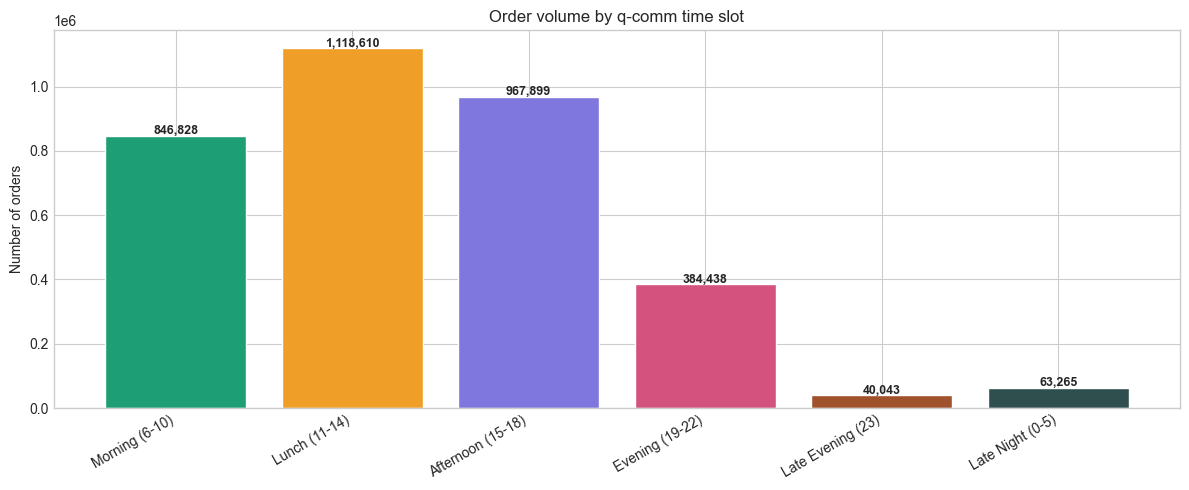

Morning (6-10)               846,828 orders (24.8%)
Lunch (11-14)              1,118,610 orders (32.7%)
Afternoon (15-18)            967,899 orders (28.3%)
Evening (19-22)              384,438 orders (11.2%)
Late Evening (23)             40,043 orders (1.2%)
Late Night (0-5)              63,265 orders (1.8%)


In [2]:
# Cell 2: Time slots (with CAST fix for DuckDB)
time_slots = query("""
    SELECT 
        CAST(order_hour_of_day AS INTEGER) AS h,
        COUNT(*) AS order_count,
        CASE 
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 0 AND 5   THEN 'Late Night (0-5)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 6 AND 10  THEN 'Morning (6-10)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 11 AND 14 THEN 'Lunch (11-14)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 15 AND 18 THEN 'Afternoon (15-18)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 19 AND 22 THEN 'Evening (19-22)'
            ELSE 'Late Evening (23)'
        END AS time_slot
    FROM orders
    GROUP BY h
    ORDER BY h
""", con)

slot_counts = time_slots.groupby('time_slot')['order_count'].sum().reindex([
    'Morning (6-10)', 'Lunch (11-14)', 'Afternoon (15-18)', 
    'Evening (19-22)', 'Late Evening (23)', 'Late Night (0-5)'
])

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#1D9E75', '#EF9F27', '#7F77DD', '#D4537E', '#A0522D', '#2F4F4F']
bars = ax.bar(range(len(slot_counts)), slot_counts.values, color=colors, edgecolor='white')
ax.set_xticks(range(len(slot_counts)))
ax.set_xticklabels(slot_counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of orders')
ax.set_title('Order volume by q-comm time slot')

for bar, val in zip(bars, slot_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE}12_time_slots.png', dpi=150, bbox_inches='tight')
plt.show()

for slot, count in slot_counts.items():
    print(f'{slot:25} {count:>10,} orders ({count/slot_counts.sum()*100:.1f}%)')

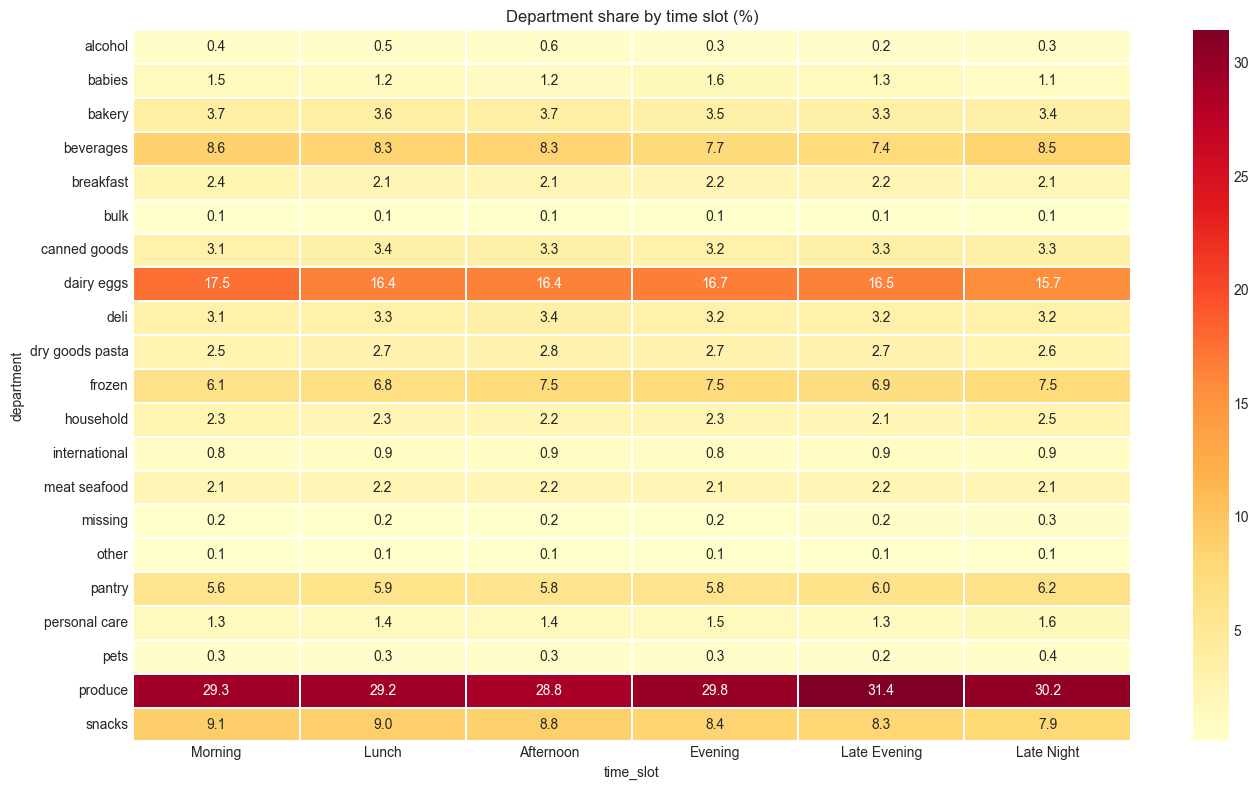

Top 3 departments per slot:
  Morning         produce              29.3%
  Morning         dairy eggs           17.5%
  Morning         snacks               9.1%
  Lunch           produce              29.2%
  Lunch           dairy eggs           16.4%
  Lunch           snacks               9.0%
  Afternoon       produce              28.8%
  Afternoon       dairy eggs           16.4%
  Afternoon       snacks               8.8%
  Evening         produce              29.8%
  Evening         dairy eggs           16.7%
  Evening         snacks               8.4%
  Late Evening    produce              31.4%
  Late Evening    dairy eggs           16.5%
  Late Evening    snacks               8.3%
  Late Night      produce              30.2%
  Late Night      dairy eggs           15.7%
  Late Night      beverages            8.5%


In [3]:
# Cell 3: Department share by time slot
slot_dept = query("""
    WITH ts AS (
        SELECT order_id,
            CASE 
                WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 0 AND 5   THEN 'Late Night'
                WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 6 AND 10  THEN 'Morning'
                WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 11 AND 14 THEN 'Lunch'
                WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 15 AND 18 THEN 'Afternoon'
                WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 19 AND 22 THEN 'Evening'
                ELSE 'Late Evening'
            END AS time_slot
        FROM orders
    )
    SELECT ts.time_slot, d.department, COUNT(*) AS item_count
    FROM ts
    JOIN order_products_prior op ON ts.order_id = op.order_id
    JOIN products p USING (product_id)
    JOIN departments d USING (department_id)
    GROUP BY ts.time_slot, d.department
""", con)

slot_totals = slot_dept.groupby('time_slot')['item_count'].sum()
slot_dept['share'] = slot_dept.apply(lambda r: r['item_count'] / slot_totals[r['time_slot']] * 100, axis=1)

pivot = slot_dept.pivot(index='department', columns='time_slot', values='share').fillna(0)
col_order = ['Morning', 'Lunch', 'Afternoon', 'Evening', 'Late Evening', 'Late Night']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Department share by time slot (%)')
plt.tight_layout()
plt.savefig(f'{SAVE}13_dept_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 departments per slot:')
for slot in col_order:
    if slot in pivot.columns:
        for dept, share in pivot[slot].nlargest(3).items():
            print(f'  {slot:15} {dept:20} {share:.1f}%')

In [4]:
# Cell 4: Basket clustering (K-Means)
features = query("""
    WITH bs AS (
        SELECT order_id, COUNT(*) AS basket_size, AVG(reordered) AS reorder_rate
        FROM order_products_prior GROUP BY order_id
    )
    SELECT bs.order_id, bs.basket_size, bs.reorder_rate,
           CAST(o.order_hour_of_day AS INTEGER) AS hour,
           o.order_dow AS dow
    FROM bs JOIN orders o ON bs.order_id = o.order_id
    WHERE bs.basket_size BETWEEN 2 AND 15
""", con)

features = features.dropna()
X = features[['basket_size', 'reorder_rate', 'hour', 'dow']].copy()
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X_scaled)

profiles = features.groupby('cluster')[['basket_size', 'reorder_rate', 'hour', 'dow']].mean()
print('Cluster profiles:')
print(profiles.round(2))
print(f'\nCluster sizes: {features["cluster"].value_counts().sort_index().to_dict()}')

Cluster profiles:
         basket_size  reorder_rate   hour   dow
cluster                                        
0               6.11          0.15  13.81  2.95
1               7.83          0.75  13.58  5.06
2               4.82          0.84  13.02  1.50
3              11.89          0.60  13.57  1.40

Cluster sizes: {0: 567087, 1: 667593, 2: 645585, 3: 556357}


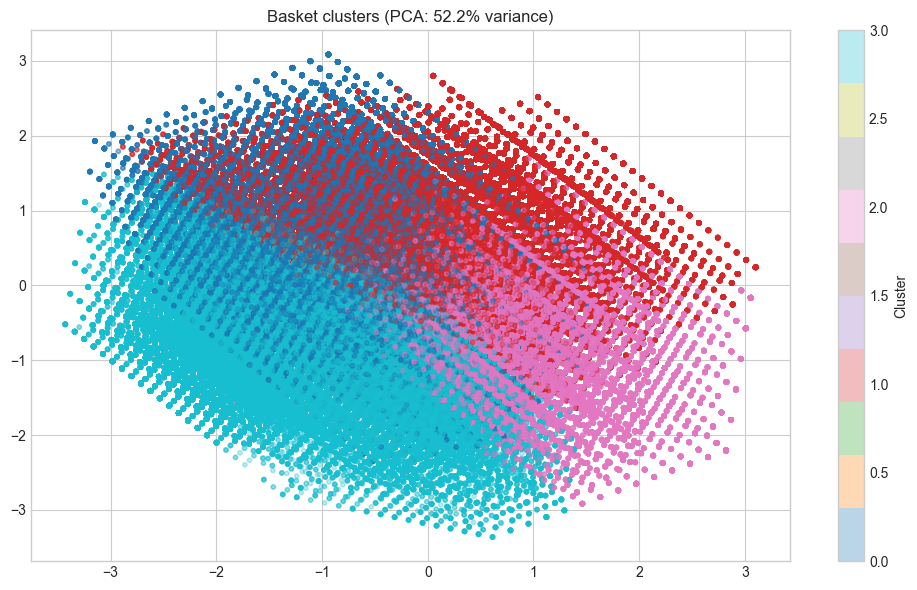

Cluster names (based on profiles):
  Cluster 0: Midday Small (size=6.1, reorder=0.15)
  Cluster 1: Midday Small (size=7.8, reorder=0.75)
  Cluster 2: Midday Small (size=4.8, reorder=0.84)
  Cluster 3: Midday Big (size=11.9, reorder=0.60)


In [5]:
# Cell 5: Visualize clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=features['cluster'], 
                     cmap='tab10', alpha=0.3, s=10)
ax.set_title(f'Basket clusters (PCA: {pca.explained_variance_ratio_.sum():.1%} variance)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(f'{SAVE}14_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cluster names (based on profiles):')
for c in range(4):
    p = profiles.loc[c]
    name = 'Morning' if p['hour'] < 8 else 'Evening' if p['hour'] > 18 else 'Midday'
    name += ' Big' if p['basket_size'] > 10 else ' Small'
    print(f'  Cluster {c}: {name} (size={p["basket_size"]:.1f}, reorder={p["reorder_rate"]:.2f})')

In [6]:
# Cell 6: Summary
print('='*50)
print('PHASE 3 COMPLETE')
print('='*50)
print(f'Time slots: 6 distinct ordering occasions identified')
print(f'Basket clusters: 4 behavioral segments found')
print(f'Key insight: Same products, different lift by time of day')
print(f'Files saved: 12_time_slots.png, 13_dept_by_time.png, 14_clusters.png')
con.close()

PHASE 3 COMPLETE
Time slots: 6 distinct ordering occasions identified
Basket clusters: 4 behavioral segments found
Key insight: Same products, different lift by time of day
Files saved: 12_time_slots.png, 13_dept_by_time.png, 14_clusters.png
